In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score , recall_score, roc_auc_score, f1_score,roc_curve

In [31]:
df = pd.read_csv('diabetes.csv')

In [32]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [33]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

numerical_features = ['Glucose','BMI','BloodPressure','Insulin']
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [34]:
selected_features = ['Age',
'DiabetesPedigreeFunction']

In [35]:
if 'Gender' in df.columns:
    df['Gender'] = LabelEncoder().fit_transform(df['Gender'])
    selected_features.append('Gender')

In [36]:
# 1 - YES , 0 - NO
target_variable ='Outcome' 

In [37]:
# Split data into features and target
X = df[selected_features]
y = df[target_variable]
# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42,stratify=y)
# Choose classification models
models = {
"Logistic Regression"
: LogisticRegression(),
"Decision Tree"
: DecisionTreeClassifier(),
"Random Forest"
: RandomForestClassifier()
}

In [38]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\n{name} Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 0.6562
              precision    recall  f1-score   support

           0       0.74      0.77      0.76        88
           1       0.44      0.40      0.42        40

    accuracy                           0.66       128
   macro avg       0.59      0.59      0.59       128
weighted avg       0.65      0.66      0.65       128



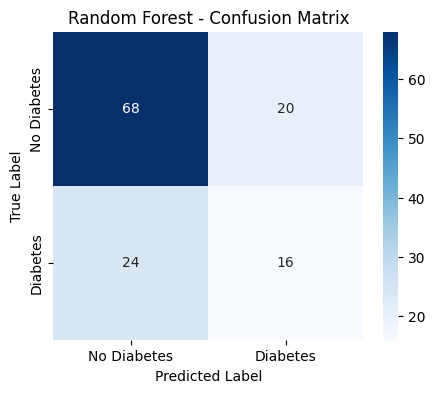

In [40]:
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap=
"Blues"
,
xticklabels=["No Diabetes"
,
"Diabetes"], yticklabels=["No Diabetes"
,
"Diabetes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"{name} - Confusion Matrix")
plt.show()

In [41]:
param_grid={
    'n_estimators':[50,100,200],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5,10]
}
grid_search=GridSearchCV(RandomForestClassifier(),param_grid,cv=5,
                        scoring='accuracy',n_jobs=-1)
grid_search.fit(X_train,y_train)
best_model=grid_search.best_estimator_
y_pred_best=best_model.predict(X_test)
print("\nOptimised random Forest model Accuracy : ")
accuracy=accuracy_score(y_test,y_pred)
print(classification_report(y_test,y_pred_best))
                        


Optimised random Forest model Accuracy : 
              precision    recall  f1-score   support

           0       0.72      0.86      0.78        88
           1       0.45      0.25      0.32        40

    accuracy                           0.67       128
   macro avg       0.59      0.56      0.55       128
weighted avg       0.63      0.67      0.64       128



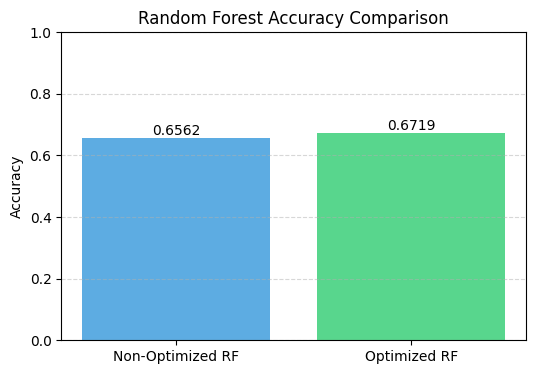

In [42]:
accuracy_default = accuracy_score(y_test, y_pred)          # Non-optimized RF
accuracy_optimized = accuracy_score(y_test, y_pred_best)   # Optimized RF
plt.figure(figsize=(6, 4))
models = ['Non-Optimized RF', 'Optimized RF']
accuracies = [accuracy_default, accuracy_optimized]
colors = ['#3498db', '#2ecc71']
bars = plt.bar(models, accuracies, color=colors, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')
plt.title('Random Forest Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

EXP 8

In [48]:
target_variable ='Outcome'
selected_features = ['Age',
'DiabetesPedigreeFunction']
X = df[selected_features]
y = df[target_variable]
X.head()


,Age,DiabetesPedigreeFunction
0,50,0.627
1,31,0.351
2,32,0.672
3,21,0.167
5,30,0.201


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}") 
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

Accuracy: 0.6562
Precision: 0.4375
Recall: 0.3500
F1 Score: 0.3889
ROC-AUC Score: 0.6929


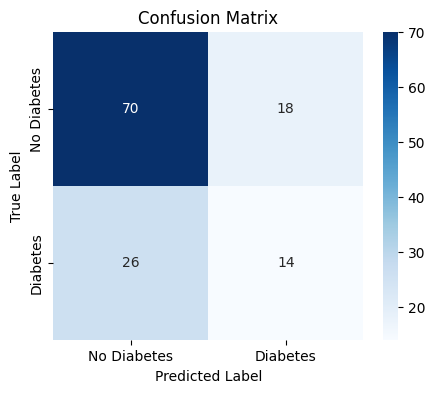

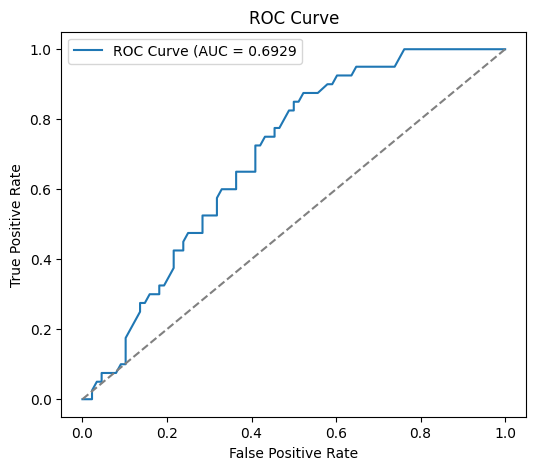

In [59]:
fpr, tpr, _= roc_curve(y_test, y_prob)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"], 
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [61]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f}")

Cross-Validation Accuracy Scores: [0.61165049 0.67647059 0.59803922 0.62745098 0.62745098]
Mean CV Accuracy: 0.6282


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"Optimized Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))

Optimized Accuracy: 0.6797
              precision    recall  f1-score   support

           0       0.73      0.85      0.79        88
           1       0.48      0.30      0.37        40

    accuracy                           0.68       128
   macro avg       0.60      0.58      0.58       128
weighted avg       0.65      0.68      0.66       128



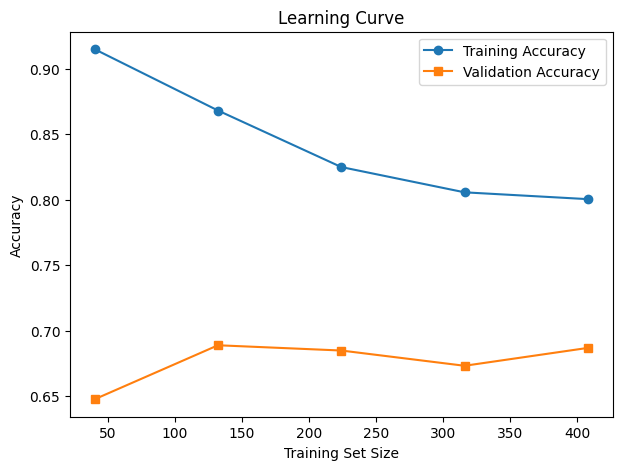

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5)
)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_mean, label="Validation Accuracy", marker='s')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()